# Exploratory Data Analysis — Air Cargo Resource Allocation

Supports the report appendix and, more importantly, establishes the two facts that shape every modelling decision in this project:

1. the dataset is synthetic and its columns are mutually independent, so no coefficient may be fitted;
2. the four terminals are near-identical, which is why the LP needs an explicit congestion multiplier to avoid degeneracy.

See `SCOPE.md` section 3 for how these findings drive the parameter derivation.

In [3]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backend.core import config, data_loader, preprocessing

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

raw = data_loader.load_bundled()
report = data_loader.validate(raw)
print(f"valid={report.ok}  rows={report.n_rows}")
for w in report.warnings:
    print("warning:", w)

df = data_loader.clean(raw)
df.shape

valid=True  rows=5000


(5000, 32)

## 1. Data quality

In [4]:
print("missing values:", int(raw.isna().sum().sum()))
print("duplicate rows:", int(raw.duplicated().sum()))
print("unique Record_ID:", raw[config.COL_RECORD_ID].nunique(), "of", len(raw))
print("unique Flight_ID:", raw[config.COL_FLIGHT_ID].nunique(), "of", len(raw))
print("date range:", df[config.COL_TIMESTAMP].min(), "to", df[config.COL_TIMESTAMP].max())

missing values: 0
duplicate rows: 0
unique Record_ID: 5000 of 5000
unique Flight_ID: 3841 of 5000
date range: 2024-01-01 01:36:00 to 2024-12-31 00:00:00


In [5]:
df[list(config.NUMERIC_COLUMNS)].describe().T[["min", "max", "mean", "std"]].round(2)

,min,max,mean,std
Cargo_Volume,5.00,119.97,62.14,33.31
Handling_Time,20.03,179.97,100.20,46.54
Waiting_Time,5.00,120.00,63.52,32.97
Workforce_Assigned,5.00,49.00,27.05,13.12
Equipment_Used,1.00,14.00,7.41,3.98
Facility_Utilization,40.01,99.99,70.33,17.44
Storage_Occupancy,30.02,99.99,65.05,20.10
Queue_Length,1.00,99.00,51.09,28.36
Flight_Delay,0.04,89.97,45.73,25.95
Operational_Cost,500.52,4998.54,2741.89,1307.46


In [6]:
for col in config.CATEGORICAL_COLUMNS:
    counts = df[col].value_counts()
    print(f"{col}: " + "  ".join(f"{k}={v}" for k, v in counts.items()))

Cargo_Type: Perishable=1290  General=1279  Hazardous=1229  Express=1202
Shipment_Priority: Medium=1537  Low=1502  High=1215  Critical=746
Arrival_Departure: Departure=2515  Arrival=2485
Terminal_ID: T2=1301  T4=1251  T3=1248  T1=1200
Equipment_Type: Loader=1275  Crane=1268  Forklift=1239  Conveyor=1218
Weather_Condition: Storm=1307  Clear=1274  Fog=1236  Rain=1183
Allocation_Strategy: Baseline=1712  Adaptive=1664  Optimized=1624
Allocation_Efficiency_Class: Low Efficiency=4356  Moderate Efficiency=632  High Efficiency=12


## 2. Finding: the columns are uniform, not normal

Skew near 0 with kurtosis near -1.2 is the signature of a uniform distribution. Combined with the correlation result below, this is what identifies the data as independently generated per column.

In [7]:
shape = pd.DataFrame({
    "skew": df[list(config.NUMERIC_COLUMNS)].skew(),
    "kurtosis": df[list(config.NUMERIC_COLUMNS)].kurtosis(),
}).round(3)
shape

,skew,kurtosis
Cargo_Volume,0.004,-1.209
Handling_Time,0.009,-1.223
Waiting_Time,-0.052,-1.186
Workforce_Assigned,-0.012,-1.216
Equipment_Used,0.033,-1.188
Facility_Utilization,-0.005,-1.216
Storage_Occupancy,-0.009,-1.190
Queue_Length,-0.039,-1.179
Flight_Delay,-0.044,-1.197
Operational_Cost,0.008,-1.209


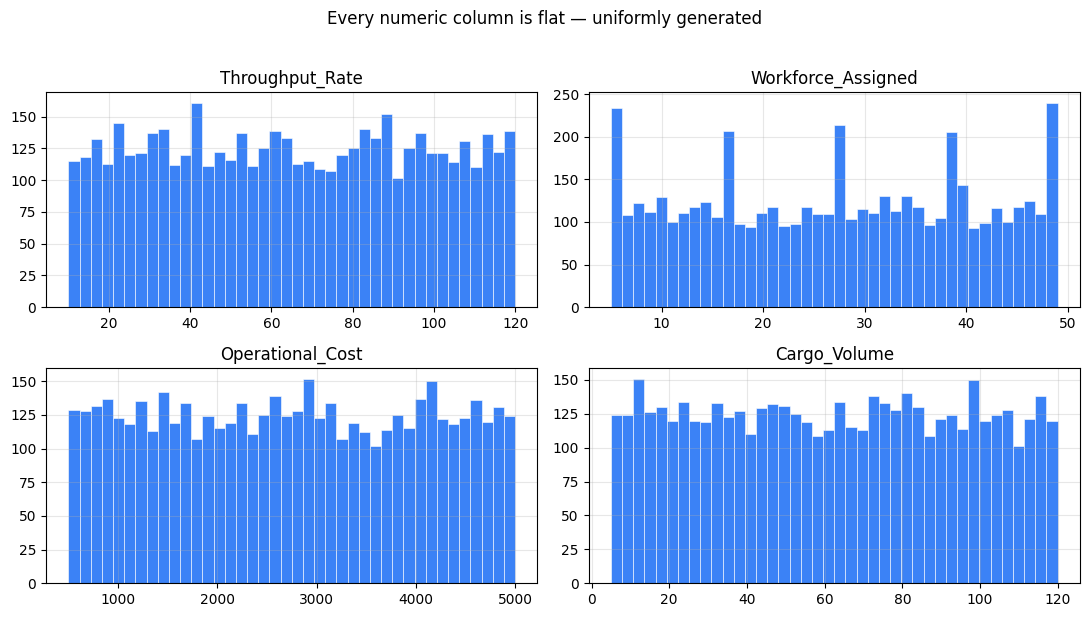

In [8]:
cols = [
    config.COL_THROUGHPUT, config.COL_WORKFORCE,
    config.COL_OPERATIONAL_COST, config.COL_CARGO_VOLUME,
]
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax, col in zip(axes.ravel(), cols):
    ax.hist(df[col], bins=40, color="#3b82f6", edgecolor="white", linewidth=0.4)
    ax.set_title(col)
fig.suptitle("Every numeric column is flat — uniformly generated", y=1.02)
fig.tight_layout()

## 3. Finding: nothing correlates with anything

This is the single most consequential result in the project. Resource inputs do not predict operational outcomes, so a regression for "throughput per worker" would return noise. Parameters must instead be derived in closed form from group means plus stated assumptions.

strongest off-diagonal |r| = 0.0361


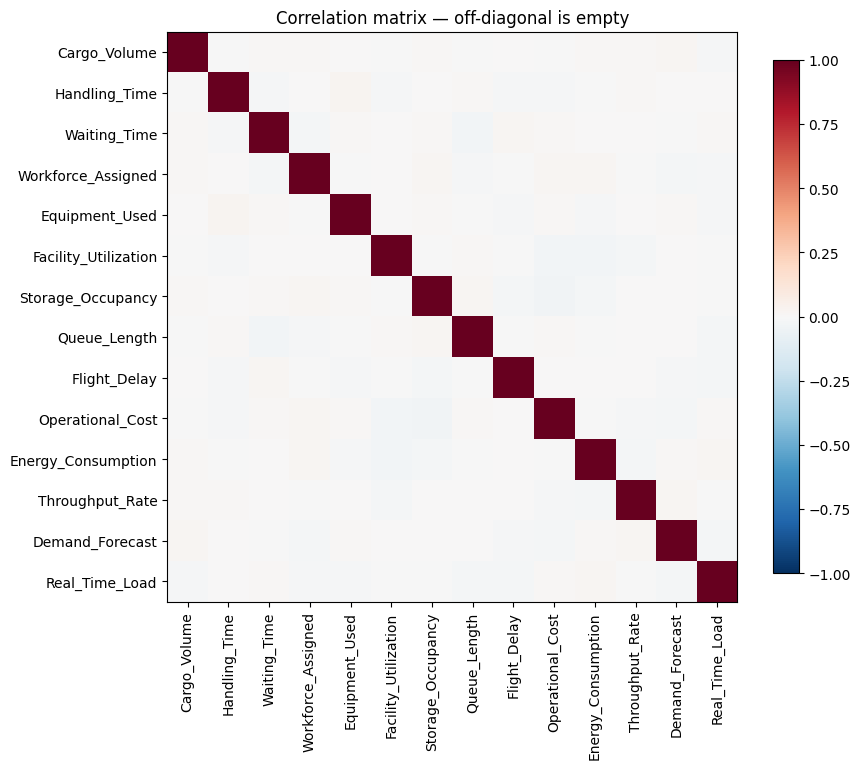

In [9]:
corr = df[list(config.NUMERIC_COLUMNS)].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix — off-diagonal is empty")
fig.tight_layout()

off = corr.where(~np.eye(len(corr), dtype=bool)).abs()
print(f"strongest off-diagonal |r| = {off.max().max():.4f}")

In [10]:
pairs = [
    (config.COL_WORKFORCE, config.COL_THROUGHPUT),
    (config.COL_EQUIPMENT, config.COL_HANDLING_TIME),
    (config.COL_CARGO_VOLUME, config.COL_OPERATIONAL_COST),
    (config.COL_QUEUE_LENGTH, config.COL_WAITING_TIME),
]
for a, b in pairs:
    print(f"corr({a}, {b}) = {df[a].corr(df[b]):+.4f}")

corr(Workforce_Assigned, Throughput_Rate) = -0.0073
corr(Equipment_Used, Handling_Time) = +0.0237
corr(Cargo_Volume, Operational_Cost) = -0.0014
corr(Queue_Length, Waiting_Time) = -0.0256


## 4. Finding: the terminals are nearly interchangeable

Mean throughput, cost and handling time differ by ~2% across T1–T4. Uniform productivity coefficients would leave the LP indifferent between terminals, and the "optimum" would be an artefact of solver scan order rather than a decision.

Bottleneck rate and facility utilisation are the two signals that do vary, so they supply the congestion multiplier.

In [11]:
summary = preprocessing.terminal_summary(df)
summary.round(3)

,n_records,mean_workforce,mean_equipment,mean_throughput,mean_cost,mean_demand_forecast,mean_facility_util,mean_storage_occupancy,bottleneck_rate,workforce_min,workforce_max,equipment_min,equipment_max,throughput_capacity
terminal,,,,,,,,,,,,,,
T1,1200,27.430,7.541,64.570,2711.622,79.005,70.995,65.470,0.310,7.0,47.00,1.0,14.0,114.991
T2,1301,26.657,7.470,65.909,2688.500,80.128,69.822,65.300,0.292,6.0,48.00,1.0,14.0,115.510
T3,1248,26.847,7.358,64.610,2787.134,79.789,69.992,64.690,0.276,7.0,47.65,1.0,14.0,114.166
T4,1251,27.281,7.264,65.037,2781.309,80.971,70.556,64.736,0.291,7.0,47.00,1.0,13.5,114.365


In [12]:
spread = summary[["mean_throughput", "mean_cost", "mean_workforce", "bottleneck_rate"]]
print((spread.max() / spread.min() - 1).mul(100).round(2).to_string())
print("\n^ percentage spread between the best and worst terminal on each metric")

mean_throughput     2.07
mean_cost           3.67
mean_workforce      2.90
bottleneck_rate    12.47

^ percentage spread between the best and worst terminal on each metric


Text(0.5, 1.0, 'Throughput by terminal — indistinguishable distributions')

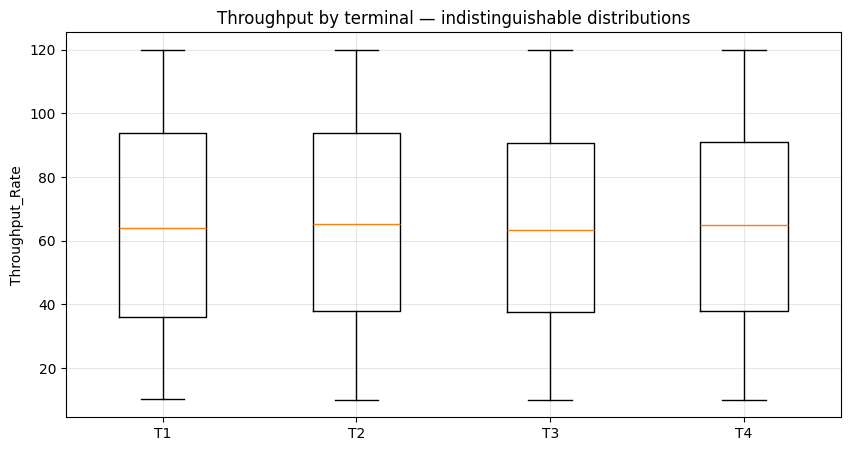

In [13]:
fig, ax = plt.subplots()
data = [df.loc[df[config.COL_TERMINAL] == t, config.COL_THROUGHPUT] for t in config.TERMINALS]
ax.boxplot(data, tick_labels=list(config.TERMINALS))
ax.set_ylabel(config.COL_THROUGHPUT)
ax.set_title("Throughput by terminal — indistinguishable distributions")

## 5. Derived LP parameters

The closed-form share method with, and without, the congestion multiplier. Note that the uncongested parameters reproduce each terminal's mean throughput exactly, while the congested ones preserve only the system total — that is the deliberate trade described in `SCOPE.md` section 3.

In [14]:
plain = preprocessing.estimate_lp_params(df, apply_congestion=False)
congested = preprocessing.estimate_lp_params(df, apply_congestion=True)

table = pd.DataFrame({
    "alpha_uncongested": plain.alpha,
    "alpha_congested": congested.alpha,
    "beta_uncongested": plain.beta,
    "beta_congested": congested.beta,
    "gamma": congested.congestion,
    "cost_worker": congested.cost_worker,
    "cost_equipment": congested.cost_equipment,
    "demand": congested.demand,
    "capacity": congested.capacity,
})
table.round(3)

,alpha_uncongested,alpha_congested,beta_uncongested,beta_congested,gamma,cost_worker,cost_equipment,demand,capacity
T1,1.412,1.346,3.425,3.264,0.200,59.314,143.837,64.248,114.991
T2,1.483,1.509,3.529,3.591,0.214,60.513,143.969,65.161,115.510
T3,1.444,1.495,3.512,3.636,0.217,62.289,151.512,64.886,114.166
T4,1.430,1.422,3.581,3.561,0.209,61.171,153.160,65.847,114.365


In [15]:
for t in plain.terminals:
    modelled = plain.alpha[t] * plain.baseline_workforce[t] + plain.beta[t] * plain.baseline_equipment[t]
    print(f"{t}: modelled={modelled:7.3f}  observed={summary.loc[t, 'mean_throughput']:7.3f}")

print(f"\nsystem baseline throughput, uncongested: {plain.baseline_throughput():.4f}")
print(f"system baseline throughput, congested:   {congested.baseline_throughput():.4f}")
print(f"observed system total:                   {summary['mean_throughput'].sum():.4f}")

T1: modelled= 64.570  observed= 64.570
T2: modelled= 65.909  observed= 65.909
T3: modelled= 64.610  observed= 64.610
T4: modelled= 65.037  observed= 65.037

system baseline throughput, uncongested: 260.1254
system baseline throughput, congested:   260.1254
observed system total:                   260.1254


## 6. Candidate shipment batch for the IP

Priority-weighted value against the three resource weights the knapsack consumes.

In [16]:
batch = preprocessing.build_batch(df, size=50)
caps = preprocessing.default_capacities(batch)

print(batch[config.COL_PRIORITY].value_counts().to_string())
print("\ncapacities at 60% of batch totals:")
for k, v in caps.items():
    print(f"  {k}: {v:,.1f}")

batch[[
    config.COL_RECORD_ID, config.COL_PRIORITY, config.COL_CARGO_TYPE,
    "value", "weight_volume", "weight_worker_minutes", "weight_equipment",
]].head(10).round(2)

Shipment_Priority
Low         17
Medium      15
High        13
Critical     5

capacities at 60% of batch totals:
  volume: 1,683.3
  worker_minutes: 83,632.6
  equipment: 213.0


,Record_ID,Shipment_Priority,Cargo_Type,value,weight_volume,weight_worker_minutes,weight_equipment
0,3600,Critical,Perishable,13.71,81.09,3496.29,3
1,4967,Low,Hazardous,1.54,116.24,6266.04,2
2,1118,Low,Perishable,1.71,105.91,3214.40,2
3,487,High,Express,6.76,10.23,2846.61,8
4,1963,High,General,9.90,101.58,2223.80,9
5,502,High,Perishable,5.41,66.65,5272.93,4
6,229,Critical,Express,15.74,107.59,5351.20,14
7,706,Low,Perishable,1.97,118.85,3581.10,9
8,839,Medium,General,3.37,71.77,893.52,5
9,1056,High,General,9.54,45.33,3812.50,2


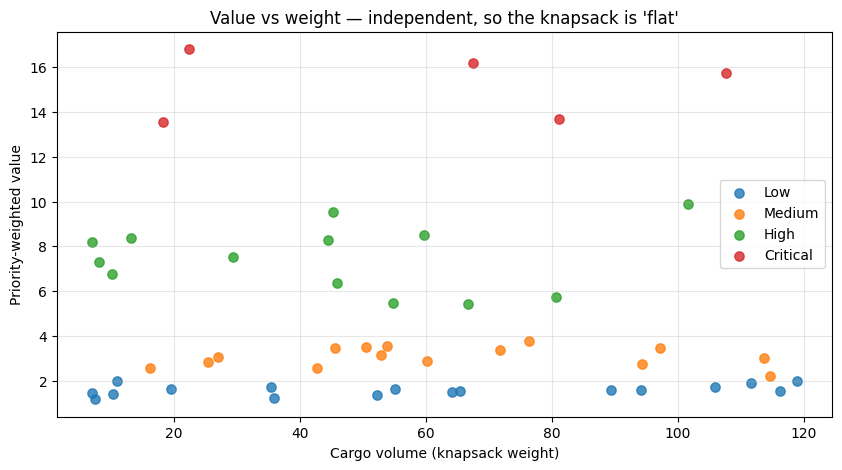

In [17]:
fig, ax = plt.subplots()
for priority in config.PRIORITIES:
    sel = batch[batch[config.COL_PRIORITY] == priority]
    ax.scatter(sel["weight_volume"], sel["value"], label=priority, s=45, alpha=0.8)
ax.set_xlabel("Cargo volume (knapsack weight)")
ax.set_ylabel("Priority-weighted value")
ax.set_title("Value vs weight — independent, so the knapsack is 'flat'")
ax.legend()